In [1]:
using Clapeyron, Metaheuristics, Printf

In [2]:
#Hfus dan Tm masukin ke csv yh jgn lupa

like_parameter = """Clapeyron Database File
PCSAFT Like Parameters [csvtype = like,grouptype = PCSAFT]
species,Mw,segment,sigma,epsilon,n_H,n_e
water,18.02,1.2047,2.801457,353.94,1,1
ethylamine,45.09,2.7046,3.1343,221.53,1,1
"""

unlike_parameter = """Clapeyron Database File
PCSAFT Unlike Parameters [csvtype = unlike,grouptype = PCSAFT]
species1,species2,k
water,ethylamine,-0.01
"""

assoc_parameter = """Clapeyron Database File
PCSAFT Assoc Parameters [csvtype = assoc,grouptype = PCSAFT]
species1,site1,species2,site2,epsilon_assoc,bondvol
ethylamine,H,ethylamine,e,854.7,0.017275
water,H,water,e,2425.67,0.045
ethylamine,H,water,e,1640.185,0.027837577
ethylamine,e,water,H,1640.185,0.027837577
"""

model = PCSAFT(["water", "ethylamine"], userlocations = [like_parameter, unlike_parameter, assoc_parameter])

println(model.params.epsilon.values)
println(model.params.sigma.values)
println("======================")
println("kij = ", (1  - ((model.params.epsilon.values[2])/(sqrt(model.params.epsilon.values[1] * model.params.epsilon.values[4])))))

[353.94 282.8150201046967; 282.8150201046967 221.53]
[2.8014570000000003e-10 2.9678785e-10; 2.9678785e-10 3.1343e-10]
kij = -0.010000000000000009


In [3]:
function vle_p(model::EoSModel, x_water::Float64)
    P = 93300 #ganti sesuai available data
    bub = bubble_temperature(model, P, [x_water , 1-x_water])
    T = bub[1]
    y = bub[4][1]
    return T
end

function vle_y(model::EoSModel, x_water::Float64)
    P = 93300 #ganti sesuai available data
    bub = bubble_temperature(model, P, [x_water , 1-x_water])
    p = bub[1]
    y = bub[4][1]
    return y
end

vle_y (generic function with 1 method)

In [4]:
toestimate = [
    Dict(
        :param   => :epsilon,
        :indices => (1,2),
        :lower   => 80.,
        :upper   => 500.0,
        :guess   => 179.
    )
]

1-element Vector{Dict{Symbol, Any}}:
 Dict(:upper => 500.0, :param => :epsilon, :indices => (1, 2), :guess => 179.0, :lower => 80.0)

In [18]:
# Run this ONCE to fix your CSV files
function fix_line_endings(filename)
    content = read(filename, String)
    fixed = replace(content, "\r\n" => "\n")
    write(filename, fixed)
    println("Fixed: $filename")
end

fix_line_endings("vlep_ethylamine.csv")
fix_line_endings("vley_ethylamine.csv")

estimator, objective, x0, upper, lower = Estimation(
    model,
    toestimate,
    [
        "vlep_ethylamine.csv"
        "vley_ethylamine.csv"
    ]
)
 
println("Initial objective value: ", objective(x0))

Fixed: vlep_ethylamine.csv
Fixed: vley_ethylamine.csv
Initial objective value: 1.0e100


In [19]:
method = ECA(; options = Options(iterations = 1000000, seed = 42))
 
params_opt, model_opt = optimize(objective, estimator, method)

([316.4194640111527], PCSAFT{BasicIdeal, Float64}("water", "ethylamine"))

In [20]:
println(model_opt.params.epsilon.values)
println(model_opt.params.sigma.values)
println("kij = ", (1  - ((model_opt.params.epsilon.values[2])/(sqrt(model_opt.params.epsilon.values[1] * model_opt.params.epsilon.values[4])))))

[353.94 316.4194640111527; 316.4194640111527 221.53]
[2.8014570000000003e-10 2.9678785e-10; 2.9678785e-10 3.1343e-10]
kij = -0.13000949713687748


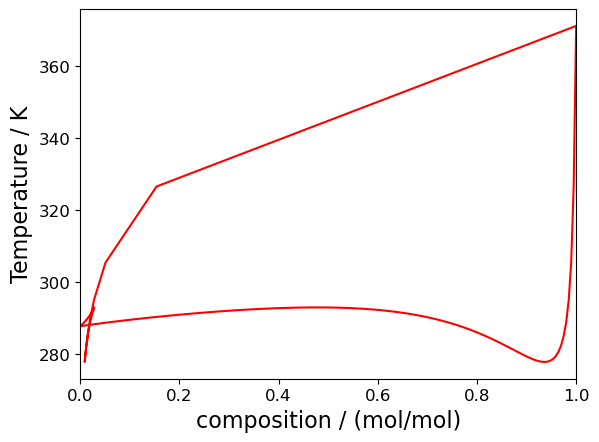

([260.0, 280.0, 300.0, 320.0, 340.0, 360.0, 380.0], PyCall.PyObject[PyObject Text(0, 260.0, '260'), PyObject Text(0, 280.0, '280'), PyObject Text(0, 300.0, '300'), PyObject Text(0, 320.0, '320'), PyObject Text(0, 340.0, '340'), PyObject Text(0, 360.0, '360'), PyObject Text(0, 380.0, '380')])

In [21]:
import PyPlot; const plt = PyPlot
using Clapeyron

N    = 201
p    = 93300

x    = LinRange(0., 1.,  N)
T    = zeros(N)
y    = zeros(N)

v0 = nothing
for i in 1:N
    if i==1
        bub = bubble_temperature(model, p, [x[i], 1-x[i]])
        T[i] = bub[1]
        y[i] = bub[4][1]
        v0   = vcat(bub[1],log10.([bub[2],bub[3]]),[x[i+1],1-x[i+1]])
    else
        bub = bubble_temperature(model, p, [x[i], 1-x[i]]; v0 = v0)
        T[i] = bub[1]
        y[i] = bub[4][1]
        v0   = vcat(bub[1],log10.([bub[2],bub[3]]),bub[4])
        if abs(y[i] - x[i])/x[i] < 1e-3
            idxend = i
            break
        end
    end
end

plt.clf()
plt.plot(x, T, color="red")
plt.plot(y, T, color="red")
plt.xlabel("composition / (mol/mol)",fontsize=16)
plt.ylabel("Temperature / K",fontsize=16)
plt.xlim([0,1])
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)

In [22]:
using CSV, DataFrames, Printf

function calculate_AAD(model, csv_file, property_func)
    df = CSV.read(csv_file, DataFrame, comment="#", skipto=4)
    
    input_col  = names(df)[1]          # first column = input (T)
    output_col = names(df)[2]          # second column = out_xxx (experimental)
    
    inputs   = df[!, input_col]
    exp_vals = df[!, output_col]
    
    println("\n=== AAD: $csv_file ===")
    @printf("%-10s  %-12s  %-12s  %-8s\n", input_col, "exp", "calc", "ARD%")
    
    errors = Float64[]
    for (i, x) in enumerate(inputs)
        calc = property_func(model, x)
        err  = abs(calc - exp_vals[i]) / abs(exp_vals[i]) * 100
        push!(errors, err)
        @printf("%-10.4f  %-12.6f  %-12.6f  %-8.4f\n", x, exp_vals[i], calc, err)
    end
    
    aard = sum(errors) / length(errors)
    @printf("AARD = %.4f%%\n", aard)
    return aard
end

calculate_AAD (generic function with 1 method)

In [23]:
aard_p   = calculate_AAD(model_opt, "vlep_ethylamine.csv", vle_p)


=== AAD: vlep_ethylamine.csv ===
Clapeyron Estimator  exp           calc          ARD%    
0.1000      290.839400    289.729010    0.3818  
0.2000      293.737800    291.562316    0.7406  
0.3000      297.536200    293.447412    1.3742  
0.4000      302.934100    295.634341    2.4097  
0.5000      308.731800    298.459105    3.3274  
0.6000      315.129400    302.475601    4.0154  
0.7000      323.626900    308.723764    4.6050  
0.8000      333.124000    319.395155    4.1212  
0.9000      343.524000    339.320433    1.2237  
0.9500      354.323000    354.655599    0.0939  
AARD = 2.2293%


┌ Warning: thread = 1 warning: parsed expected 1 columns, but didn't reach end of line around data row: 1. Parsing extra columns and widening final columnset
└ @ CSV C:\Users\sutha\.julia\packages\CSV\XLcqT\src\file.jl:593


2.229293132887808

In [24]:
aard_p   = calculate_AAD(model_opt, "vley_ethylamine.csv", vle_y)


=== AAD: vley_ethylamine.csv ===
Clapeyron Estimator  exp           calc          ARD%    
0.1000      0.005000      0.003822      23.5646 
0.2000      0.012000      0.006744      43.8021 
0.3000      0.023000      0.009604      58.2452 
0.4000      0.039000      0.012972      66.7378 
0.5000      0.058000      0.017677      69.5217 
0.6000      0.088000      0.025490      71.0337 
0.7000      0.144000      0.041326      71.3015 
0.8000      0.224000      0.083291      62.8164 


┌ Warning: thread = 1 warning: parsed expected 1 columns, but didn't reach end of line around data row: 1. Parsing extra columns and widening final columnset
└ @ CSV C:\Users\sutha\.julia\packages\CSV\XLcqT\src\file.jl:593


0.9000      0.342000      0.246809      27.8337 
0.9500      0.572000      0.503505      11.9747 
AARD = 50.6831%


50.68314217736618